In [ ]:
###
    # This code plot the inter-model relationships between permafrost-region mean soil water content (liquid + frozen) 
    # and seasonal soil temperature sensitivity at depths of (a) 1.6 m, (b) 2.4 m, and (c) 3.2 m across the circumpolar Northern Hemisphere permafrost region. 
    # 1. Read soil water content data.
    # 2. Calculate water density (kg/m³) and interpolate onto a uniform vertical grid.
    # 3. Mask grid cells within permafrost regions, then calculate multi-year mean and area-weighted average within the region.
    # 4. Calculate total water content in the upper 1.6 m, 2.4 m, and 3.2 m.
    # 5. Reconstruct the vertical distribution of soil water for models that only provide bulk soil-column water content based on the above water content vertical profile.
    # 6. Calculate seasonal soil temperature sensitivity for each grid cell, then compute the regional average over permafrost regions.
    # 7. Output: Figure S13.
###

In [2]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
warnings.filterwarnings('ignore')

In [6]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, accounting for grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [7]:
dz = 0.1  # m

# ===============================
# Define fraction calculation function
# ===============================
def calc_all_fractions(profile, total_depth_m):

    n_total = int(total_depth_m / dz)
    n_total = min(n_total, len(profile))

    total = np.sum(profile[:n_total] * dz)

    if total == 0:
        return np.nan, np.nan, np.nan

    f_02_16 = np.sum(profile[2:16] * dz) / total
    f_02_24 = np.sum(profile[2:24] * dz) / total
    f_02_32 = np.sum(profile[2:32] * dz) / total

    return f_02_16, f_02_24, f_02_32

# ===============================
# Read permafrost mask
# ===============================
probability_file = "../Data/probability_lt_threshold_320.nc"
# Read probability threshold data
ds_prob = xr.open_dataset(probability_file)
#ds_prob = ds_prob.sel(lon=slice(0, 186))

# Select grid points with probability_lt_threshold > 0
mask = ds_prob['probability_lt_threshold'] > 0

# Create grid for probability data
lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

results = {}

In [13]:
def cal_water_profile(models):

    # Create empty list to store area-weighted average of total water for each model
    depth_profiles_all_models = []

    # Data folder paths
    data_folder = "/home/wangjx/Data/cmip6_mrsfl/"
    data_folder2 = "/home/wangjx/Data/cmip6_mrsll/"


    # Loop over each model
    for fi, model in enumerate(models):
        print(f"Processing model: {model}")
            
        filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
        # Read soil water content data
        ds = xr.open_dataset(filepath)
        ds = ds.sel(lat=slice(45, 77.3))

        try:
            # Select time period from 1982 to 2014
            years = np.array([dt.year for dt in ds.time.values])
            year_mask = (years >= 1982) & (years <= 2014)
            ds = ds.isel(time=year_mask)
        except:
            ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

        filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
        # Read soil water content data
        ds2 = xr.open_dataset(filepath2)
        ds2 = ds2.sel(lat=slice(45, 77.3))

        try:
            # Select time period from 1982 to 2014
            years = np.array([dt.year for dt in ds2.time.values])
            year_mask = (years >= 1982) & (years <= 2014)
            ds2 = ds2.isel(time=year_mask)
        except:
            ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

        total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

        try:
            depth = ds['depth']
            depth_bnds = ds['depth_bnds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            try:
                depth = ds['sdepth']
                depth_bnds = ds['sdepth_bounds']
                thickness = np.empty(len(depth))
                for i in range(len(depth)):
                    thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
            except:
                zhalf_soil = ds['zhalf_soil'].values
                thickness = np.diff(zhalf_soil)         # Calculate thickness
        # Calculate water density (kg/m³)
        density_water_content = total / thickness[None, :, None, None]

        # Create new depth coordinate
        new_depths = np.arange(0.1, 10.1, 0.1)

        # Interpolation
        try:
            density_water_content_interp = density_water_content.interp(
                depth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        except:
            density_water_content_interp = density_water_content.interp(
                sdepth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        # Remove negative values
        density_water_content_interp = density_water_content_interp.clip(min=0)

        # Create grid for soil data
        lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
        
        # Create grid for probability data
        lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
        
        # Interpolate mask to soil data grid
        mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                                mask.values.ravel(),
                                (lon_soil.ravel(), lat_soil.ravel()), 
                                method='nearest')
        
        mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

        # Create mask array with same dimensions as soil data
        mask_da = xr.DataArray(mask_interp, 
                                coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                                dims=['lat', 'lon'])

        # Apply mask to filter data
        density_water_masked = density_water_content_interp.where(mask_da, drop=False)

        # Apply land mask
        try:
            sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
        except:
            sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
        land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
        if np.nanmax(land_mask_aligned) == 100:
            land_mask = land_mask_aligned > 50
        else:
            land_mask = land_mask_aligned > 0.5

        density_water_masked = density_water_masked.where(land_mask)
        # Calculate multi-year mean
        mean_yearly_range = density_water_masked.mean(dim='time')

        # ===============================
        # Area weighting (per depth level)
        # ===============================
        lat = mean_yearly_range.lat.values
        lon = mean_yearly_range.lon.values

        depth_profile_weighted = np.zeros(len(new_depths))

        for i in range(len(new_depths)):
            data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
            depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

        depth_profiles_all_models.append(depth_profile_weighted)
    return depth_profiles_all_models

In [14]:
def cal_mrso_model(depth_profiles_all_models, target_models, results):
    
    mrso_folder = "/home/wangjx/Data/cmip6_mrso/"

    for model in target_models:

        print(f"\n==== Processing {model} ====")

        # ---------------------------
        # 1. Read total soil column depth
        # ---------------------------
        if model in ["CESM2","FGOALS-g3","FGOALS-f3-L","E3SM-1-1"]:
            total_depth = 8.02999973297119
        else:
            tsl_file = glob.glob(f"/home/jidy/Data/tas-tsl-merge/tsl_{model}_*.nc")[0]
            ds_tsl = xr.open_dataset(tsl_file)
            total_depth = float(ds_tsl['depth'].values[-1])
            total_depth = np.round(total_depth, 1)

        print("Total depth:", total_depth)

        # ---------------------------
        # 2. Calculate fractions (from CESM + NorESM)
        # ---------------------------
        f1_list, f2_list, f3_list = [], [], []

        for profile in depth_profiles_all_models:
            f1, f2, f3 = calc_all_fractions(profile, total_depth)
            f1_list.append(f1)
            f2_list.append(f2)
            f3_list.append(f3)

        frac_02_16 = np.nanmean(f1_list)
        frac_02_24 = np.nanmean(f2_list)
        frac_02_32 = np.nanmean(f3_list)

        print("Fractions:", frac_02_16, frac_02_24, frac_02_32)

        # ---------------------------
        # 3. Read mrso data
        # ---------------------------
        filepath = glob.glob(mrso_folder + f"mrso_Lmon_{model}_*.nc")[0]

        ds = xr.open_dataset(filepath)
        ds = ds.sel(lat=slice(45, 77.3))

        try:
            years = np.array([dt.year for dt in ds.time.values])
            mask_time = (years >= 1982) & (years <= 2014)
            ds = ds.isel(time=mask_time)
        except:
            ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

        mrso = ds['mrso']  # (time, lat, lon)

        # ---------------------------
        # 4. Interpolate permafrost mask
        # ---------------------------

        lon_soil, lat_soil = np.meshgrid(mrso.lon.values, mrso.lat.values)

        mask_interp = griddata(
            (lon_prob.ravel(), lat_prob.ravel()),
            mask.values.ravel(),
            (lon_soil.ravel(), lat_soil.ravel()),
            method='nearest'
        )

        mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

        mask_da = xr.DataArray(mask_interp,
                            coords={'lat': mrso.lat, 'lon': mrso.lon},
                            dims=['lat', 'lon'])

        mrso = mrso.where(mask_da, drop=False)

        # ---------------------------
        # 5. Land mask
        # ---------------------------
        if model == 'FGOALS-f3-L':
            mrso = mrso
        else:
            try:
                sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
            except:
                sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
            # Align to mrso grid
            sftlf_aligned = sftlf.reindex_like(mrso, method='nearest', tolerance=0.01)
            land_mask = sftlf_aligned > 50 if np.nanmax(sftlf_aligned) == 100 else sftlf_aligned > 0.5

            mrso = mrso.where(land_mask)
        # ---------------------------
        # 6. Time average
        # ---------------------------
        mrso_mean = mrso.mean(dim='time')

        lat = mrso_mean.lat.values
        lon = mrso_mean.lon.values

        # ---------------------------
        # 7. Area-weighted mean
        # ---------------------------
        warea_mean = area_weight_mean(mrso_mean.values, lat, lon)
        print("Area-weighted mean:", warea_mean)
        # ---------------------------
        # 8. Calculate layer water content
        # ---------------------------
        water_02_16 = warea_mean * frac_02_16
        water_02_24 = warea_mean * frac_02_24
        water_02_32 = warea_mean * frac_02_32

        print("Results (kg m-2):", water_02_16, water_02_24, water_02_32)

        results[model] = (water_02_16, water_02_24, water_02_32)
        
    return results

In [15]:
models = ["CESM2","CESM2-FV2", "CESM2-WACCM", "NorESM2-LM", "NorESM2-MM"]
depth_profiles_all_models = cal_water_profile(models)

# ===============================
# Target models
# ===============================
target_models = ["MPI-ESM1-2-LR","MPI-ESM1-2-HR",
                 "FGOALS-g3","FGOALS-f3-L","E3SM-1-1"]

results = cal_mrso_model(depth_profiles_all_models,target_models,results)

# ===============================
# Print result
# ===============================
print("\n==== results ====")
for k, v in results.items():
    print(k, v)

Processing model: CESM2


Processing model: CESM2-FV2
Processing model: CESM2-WACCM
Processing model: NorESM2-LM
Processing model: NorESM2-MM

==== Processing MPI-ESM1-2-LR ====
Total depth: 7.0
Fractions: 0.38485563115414634 0.510075500366717 0.605013755006534
Area-weighted mean: 629.2080694560341
Results (kg m-2): 242.15426869778395 320.9436208625626 380.67953678200723

==== Processing MPI-ESM1-2-HR ====
Total depth: 7.0
Fractions: 0.38485563115414634 0.510075500366717 0.605013755006534
Area-weighted mean: 604.8288425527069
Results (kg m-2): 232.77178594085382 308.50837450129427 365.9297691690689

==== Processing FGOALS-g3 ====
Total depth: 8.02999973297119
Fractions: 0.3609138233048772 0.4783408622145536 0.5673688613656547
Area-weighted mean: 1089.8598146086033
Results (kg m-2): 393.3454725567357 521.3244834128728 618.3525220626667

==== Processing FGOALS-f3-L ====
Total depth: 8.02999973297119
Fractions: 0.3609138233048772 0.4783408622145536 0.5673688613656547
Area-weighted mean: 685.5418925822408
Results (

In [16]:
models = ["CNRM-CM6-1", "CNRM-ESM2-1" ]
depth_profiles_all_models = cal_water_profile(models)

# ===============================
# Target models
# ===============================
target_models = ["CNRM-CM6-1-HR"]

results = cal_mrso_model(depth_profiles_all_models,target_models,results)

# ===============================
# Print result
# ===============================
print("\n==== results ====")
for k, v in results.items():
    print(k, v)

Processing model: CNRM-CM6-1


Processing model: CNRM-ESM2-1

==== Processing CNRM-CM6-1-HR ====
Total depth: 10.0
Fractions: 0.12335397485612343 0.20081565093132353 0.2818445198805527
Area-weighted mean: 4574.910308800703
Results (kg m-2): 564.3333712008218 918.7135916142356 1289.4133994805252

==== results ====
MPI-ESM1-2-LR (242.15426869778395, 320.9436208625626, 380.67953678200723)
MPI-ESM1-2-HR (232.77178594085382, 308.50837450129427, 365.9297691690689)
FGOALS-g3 (393.3454725567357, 521.3244834128728, 618.3525220626667)
FGOALS-f3-L (247.421545487518, 327.92269998198594, 388.9551230128419)
E3SM-1-1 (466.1222951114839, 617.7799966190454, 732.7601736416352)
CNRM-CM6-1-HR (564.3333712008218, 918.7135916142356, 1289.4133994805252)


In [17]:
models = ["GFDL-ESM4"]
depth_profiles_all_models = cal_water_profile(models)

# ===============================
# Target models
# ===============================
target_models = [
                  "GFDL-CM4"
                 ]

results = cal_mrso_model(depth_profiles_all_models,target_models,results)

# ===============================
# Print result
# ===============================
print("\n==== results ====")
for k, v in results.items():
    print(k, v)

Processing model: GFDL-ESM4



==== Processing GFDL-CM4 ====
Total depth: 8.8
Fractions: 0.151134616009349 0.24616488414214532 0.3414384944773365
Area-weighted mean: 3814.541161296822
Results (kg m-2): 576.5092136644514 939.0060830260767 1302.4311912350176

==== results ====
MPI-ESM1-2-LR (242.15426869778395, 320.9436208625626, 380.67953678200723)
MPI-ESM1-2-HR (232.77178594085382, 308.50837450129427, 365.9297691690689)
FGOALS-g3 (393.3454725567357, 521.3244834128728, 618.3525220626667)
FGOALS-f3-L (247.421545487518, 327.92269998198594, 388.9551230128419)
E3SM-1-1 (466.1222951114839, 617.7799966190454, 732.7601736416352)
CNRM-CM6-1-HR (564.3333712008218, 918.7135916142356, 1289.4133994805252)
GFDL-CM4 (576.5092136644514, 939.0060830260767, 1302.4311912350176)


In [18]:
models = [
          "CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4"
          ]
depth_profiles_all_models = cal_water_profile(models)
# ===============================
# Target models
# ===============================
target_models = ["MIROC-ES2L","MIROC6" ]

results = cal_mrso_model(depth_profiles_all_models,target_models,results)

# ===============================
# Print result
# ===============================
print("\n==== results ====")
for k, v in results.items():
    print(k, v)

Processing model: CNRM-CM6-1


Processing model: CNRM-ESM2-1
Processing model: GFDL-ESM4

==== Processing MIROC-ES2L ====
Total depth: 9.0
Fractions: 0.14090774950240592 0.22943276841467394 0.3206874961374997
Area-weighted mean: 5757.218476402784
Results (kg m-2): 811.2366989035866 1320.894573409202 1846.2679779141597

==== Processing MIROC6 ====
Total depth: 9.0
Fractions: 0.14090774950240592 0.22943276841467394 0.3206874961374997
Area-weighted mean: 5887.674399695247
Results (kg m-2): 829.618949463986 1350.8254370462842 1888.1035613111255

==== results ====
MPI-ESM1-2-LR (242.15426869778395, 320.9436208625626, 380.67953678200723)
MPI-ESM1-2-HR (232.77178594085382, 308.50837450129427, 365.9297691690689)
FGOALS-g3 (393.3454725567357, 521.3244834128728, 618.3525220626667)
FGOALS-f3-L (247.421545487518, 327.92269998198594, 388.9551230128419)
E3SM-1-1 (466.1222951114839, 617.7799966190454, 732.7601736416352)
CNRM-CM6-1-HR (564.3333712008218, 918.7135916142356, 1289.4133994805252)
GFDL-CM4 (576.5092136644514, 939.006083

In [19]:
def layer_water(model):

    # Data folder paths
    data_folder = "/home/wangjx/Data/cmip6_mrsfl/"
    data_folder2 = "/home/wangjx/Data/cmip6_mrsll/"

    filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds = xr.open_dataset(filepath)
    ds = ds.sel(lat=slice(45, 77.3))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds = ds.isel(time=year_mask)
    except:
        ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

    filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds2 = xr.open_dataset(filepath2)
    ds2 = ds2.sel(lat=slice(45, 77.3))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds2.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds2 = ds2.isel(time=year_mask)
    except:
        ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

    total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

    try:
        depth = ds['depth']
        depth_bnds = ds['depth_bnds']
        thickness = np.empty(len(depth))
        for i in range(len(depth)):
            thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
    except:
        try:
            depth = ds['sdepth']
            depth_bnds = ds['sdepth_bounds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            zhalf_soil = ds['zhalf_soil'].values
            thickness = np.diff(zhalf_soil)         # Calculate thickness

    # Calculate water density (kg/m³)
    density_water_content = total / thickness[None, :, None, None]

    # Create new depth coordinate
    new_depths = np.arange(0.1, 10.1, 0.1)

    # Interpolation
    try:
        density_water_content_interp = density_water_content.interp(
            depth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    except:
        density_water_content_interp = density_water_content.interp(
            sdepth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    # Remove negative values
    density_water_content_interp = density_water_content_interp.clip(min=0)

    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                            dims=['lat', 'lon'])

    # Apply mask to filter data
    density_water_masked = density_water_content_interp.where(mask_da, drop=False)

    # Apply land mask
    try:
        sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
    except:
        sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
    land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
    if np.nanmax(land_mask_aligned) == 100:
        land_mask = land_mask_aligned > 50
    else:
        land_mask = land_mask_aligned > 0.5

    density_water_masked = density_water_masked.where(land_mask)
    # Calculate multi-year mean
    mean_yearly_range = density_water_masked.mean(dim='time')

    # ===============================
    # Area weighting (per depth level)
    # ===============================
    lat = mean_yearly_range.lat.values
    lon = mean_yearly_range.lon.values

    depth_profile_weighted = np.zeros(len(new_depths))

    for i in range(len(new_depths)):
        data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
        depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

    return depth_profile_weighted

In [20]:
models = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
               "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6",
               "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]
models_layer = ["CESM2","CESM2-FV2", "CESM2-WACCM", "CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4", "NorESM2-LM", "NorESM2-MM","TaiESM1"]
area_weighted_means16_total2 = []
area_weighted_means24_total2 = []
area_weighted_means32_total2 = []
for k, model in enumerate(models):
    print(model)
    print(k)
    if model in models_layer:
        area_weighted_means16_total2.append(np.sum(layer_water(model)[2:16])*0.1)
        area_weighted_means24_total2.append(np.sum(layer_water(model)[2:24])*0.1)
        area_weighted_means32_total2.append(np.sum(layer_water(model)[2:32])*0.1)
    else:
        # Get from results dictionary
        area_weighted_means16_total2.append(results[model][0])  # First value
        area_weighted_means24_total2.append(results[model][1])  # Second value
        area_weighted_means32_total2.append(results[model][2])  # Third value
area_weighted_means16_total2

CESM2
0
CESM2-FV2
1
CESM2-WACCM
2
CNRM-CM6-1-HR
3
CNRM-CM6-1
4
CNRM-ESM2-1
5
E3SM-1-1
6
FGOALS-f3-L
7
FGOALS-g3
8
GFDL-CM4
9
GFDL-ESM4
10
MIROC6
11
MIROC-ES2L
12
MPI-ESM1-2-HR
13
MPI-ESM1-2-LR
14
NorESM2-LM
15
NorESM2-MM
16
TaiESM1
17


[453.5246640599564,
 496.3282755393284,
 458.0412204277128,
 564.3333712008218,
 463.3396457380668,
 467.0651104292192,
 466.1222951114839,
 247.421545487518,
 393.3454725567357,
 576.5092136644514,
 530.5681245399813,
 829.618949463986,
 811.2366989035866,
 232.77178594085382,
 242.15426869778395,
 487.25047356418656,
 454.3811806423112,
 416.3667982247043]

In [22]:
# Data folder path
data_folder = "../Data/cmip6_tsl/"

# Create empty lists to store area-weighted means for each model
area_weighted_means32 = []
area_weighted_means24 = []
area_weighted_means16 = []

# Loop over each model
for i, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"{model}_tsl_monthly_0_3_hd.nc")[0]        
    # Read soil temperature data
    ds_soil = xr.open_dataset(filepath, decode_times=False)
    ds_soil = ds_soil.sel(lat=slice(45, 77.3))
    
    # Select grid points with probability_lt_threshold > 0
    mask = ds_prob['probability_lt_threshold'] > 0
    
    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(ds_soil.lon.values, ds_soil.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)
    
    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': ds_soil.lat, 'lon': ds_soil.lon},
                            dims=['lat', 'lon'])
    
    # Apply mask to filter data
    ds_soil_masked = ds_soil.where(mask_da, drop=False)
    
    try:
        sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
    except:
        sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3))['sftlf']
        
    if sftlf.lon[0].data == ds_soil_masked.lon[0].data:
        land_mask_aligned = sftlf.reindex_like(ds_soil_masked, method='nearest', 
                                        tolerance=0.01)  # Allow 0.01 degree tolerance
        if np.nanmax(land_mask_aligned)==100:
            land_mask = land_mask_aligned > 50  # Land grid points are True
        else:
            land_mask = land_mask_aligned > 0.5
        ds_soil_masked = ds_soil_masked.where(land_mask)
    else:
        print(model)
    
    # Get depth information
    try:
        depth_values = ds_soil.depth.values
    except:
        depth_values = ds_soil.sdepth.values
    
    # Find index of 0.2m depth layer
    depth_02m_index = None
    for j, depth in enumerate(depth_values):
        if abs(depth - 0.2) < 0.05:  # Allow 0.05m tolerance
            depth_02m_index = j
            break
    
    if depth_02m_index is None:
        print(f"  {model}: 0.2m depth layer not found, skipping this model")
        continue
    
    # Group by year and calculate annual temperature amplitude (max - min) for each year
    n_months = len(ds_soil_masked['time'])
    year_start = 1982
    years = [year_start + i//12 for i in range(n_months)]

    # Add grouping coordinate
    ds_grouped = ds_soil_masked.assign_coords(year_group=('time', years))

    # Calculate annual temperature amplitude for each layer
    yearly_amplitude = ds_grouped['tsl'].groupby('year_group').max(dim='time') - \
                      ds_grouped['tsl'].groupby('year_group').min(dim='time')
    
    # Extract temperature amplitude at 0.2m layer
    try:
        amplitude_02m = yearly_amplitude.isel(depth=depth_02m_index)
    except:
        amplitude_02m = yearly_amplitude.isel(sdepth=depth_02m_index)
    
    # Calculate amplitude ratio relative to 0.2m layer for each layer
    amplitude_ratio = yearly_amplitude / amplitude_02m
    
    # Calculate multi-year mean of amplitude ratio
    mean_amplitude_ratio = amplitude_ratio.mean(dim='year_group')
        
    # Calculate area-weighted mean and store in lists
    area_weighted_means32.append(area_weight_mean(
        mean_amplitude_ratio[-1,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

    area_weighted_means24.append(area_weight_mean(
        mean_amplitude_ratio[23,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

    area_weighted_means16.append(area_weight_mean(
        mean_amplitude_ratio[15,:,:].data, 
        mean_amplitude_ratio.lat.data, 
        mean_amplitude_ratio.lon.data
    ))

FGOALS-f3-L


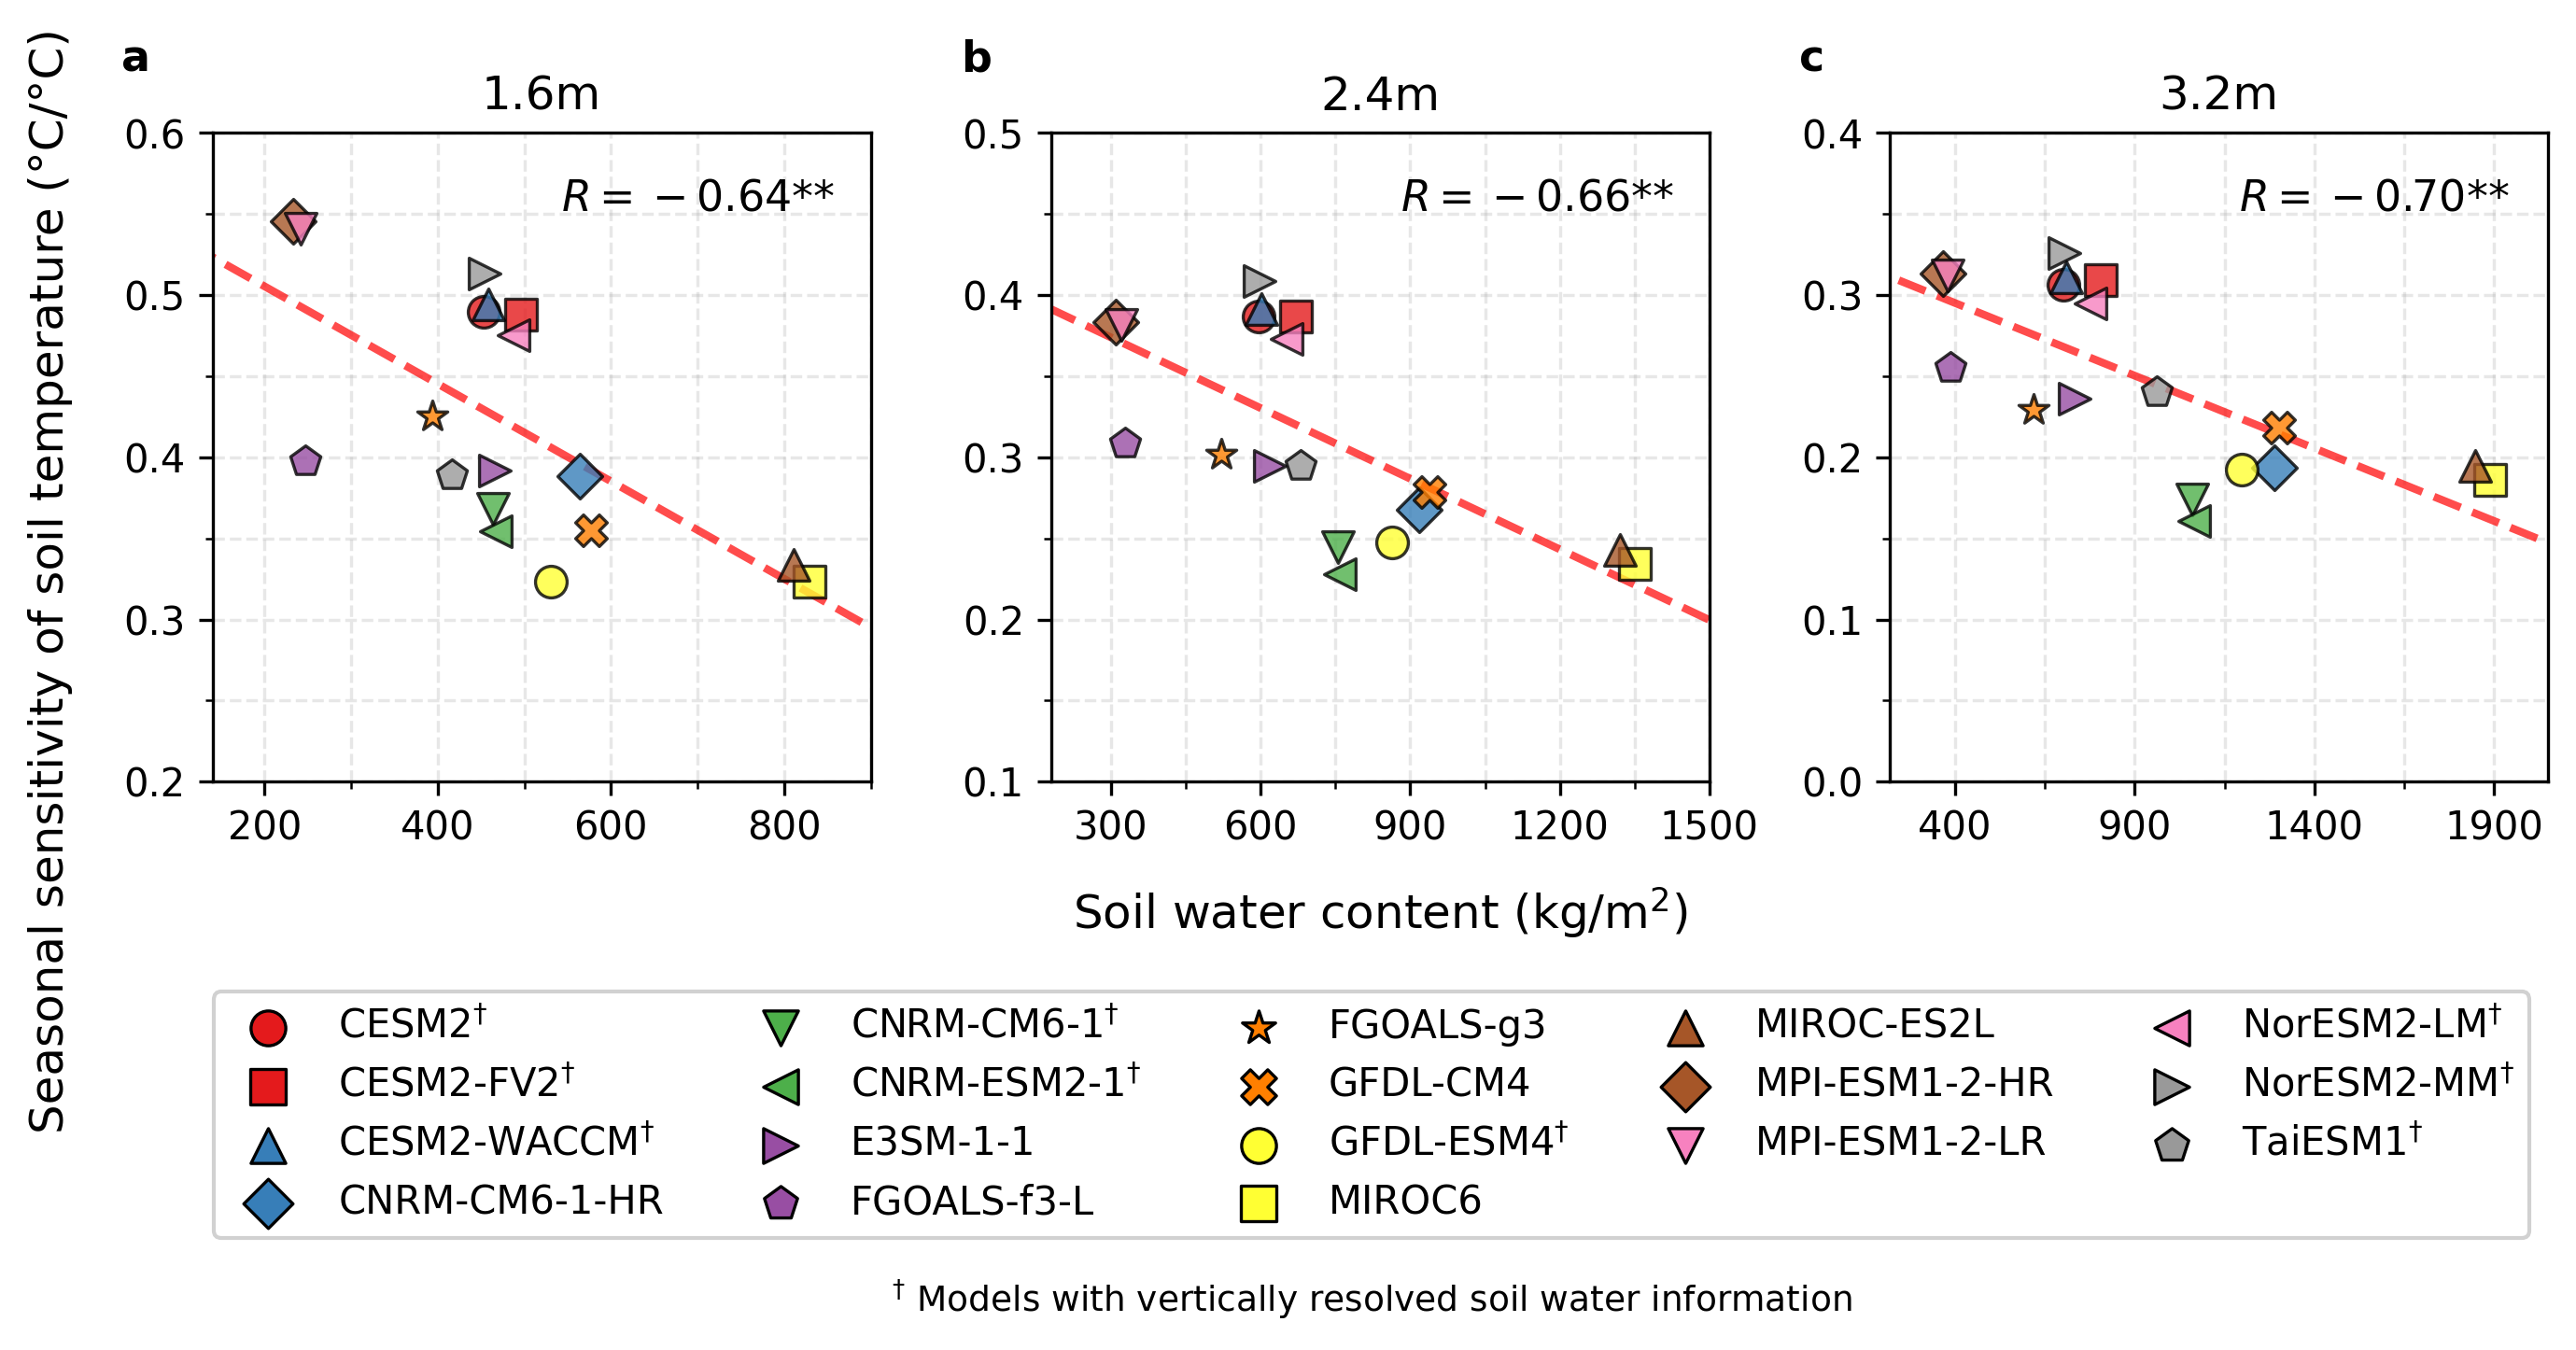

回归分析结果:

1.6m:
  回归方程: y = -0.0003x + 0.5656
  相关系数 R = -0.6357
  p值 = 0.0046
  标准误差 = 0.0001

2.4m:
  回归方程: y = -0.0001x + 0.4174
  相关系数 R = -0.6579
  p值 = 0.0030
  标准误差 = 0.0000

3.2m:
  回归方程: y = -0.0001x + 0.3311
  相关系数 R = -0.7018
  p值 = 0.0012
  标准误差 = 0.0000


In [23]:
import matplotlib.pyplot as plt
from scipy import stats
import string
from matplotlib.ticker import MultipleLocator 
from matplotlib.font_manager import FontProperties

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(9.3, 4.3), dpi=300)

# Define data for three depths
depths_data = [
    {
        'title': '1.6m',
        'x_data': area_weighted_means16_total2,  
        'y_data': area_weighted_means16,        
        'ax': axes[0]
    },
    {
        'title': '2.4m', 
        'x_data': area_weighted_means24_total2,  
        'y_data': area_weighted_means24,        
        'ax': axes[1]
    },
    {
        'title': '3.2m',
        'x_data': area_weighted_means32_total2,  
        'y_data': area_weighted_means32,        
        'ax': axes[2]
    }
]

# Define different markers and colors
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
colors = plt.cm.Set1(np.linspace(0, 1, len(models)))
LETTERS = list(string.ascii_lowercase)[:3]
layered_models = [
    "CESM2",
    "CESM2-FV2",
    "CESM2-WACCM",
    "CNRM-CM6-1",
    "CNRM-ESM2-1",
    "GFDL-ESM4",
    "NorESM2-LM",
    "NorESM2-MM",
    "TaiESM1"
]
# Plot scatter plots for each depth
for j, depth_info in enumerate(depths_data):
    ax = depth_info['ax']
    x_data = depth_info['x_data']
    y_data = depth_info['y_data']
    
    # Draw scatter points
    for i, model in enumerate(models):
        ax.scatter(x_data[i], y_data[i], 
                  c=[colors[i]], 
                  marker=markers[i % len(markers)],
                  s=66, 
                  alpha=0.8,
                  edgecolors='black', 
                  linewidth=0.8,
                  zorder=3,
                  label=model if depth_info['title'] == '1.6m' else "")  # Only add legend label on the first subplot
    
    # Set axis labels
    if depth_info['title'] == '2.4m':
        ax.set_xlim(180,1500)
        ax.set_ylim(0.1, 0.5)
        ax.set_xlabel('Soil water content (kg/m$^{2}$)', 
                  fontsize=12, labelpad=9.5)
        ax.xaxis.set_major_locator(MultipleLocator(300))   # Major tick labels
        ax.xaxis.set_minor_locator(MultipleLocator(150))  # Minor tick lines

    if depth_info['title'] == '1.6m':
        ax.set_xlim(140,900)
        ax.set_ylim(0.2, 0.6)
        ax.set_ylabel('Seasonal sensitivity of soil temperature (°C/°C)', 
                  fontsize=12, labelpad=13, y=0.31)
        ax.xaxis.set_major_locator(MultipleLocator(200))   # Major tick labels
        ax.xaxis.set_minor_locator(MultipleLocator(100))  # Minor tick lines

    if depth_info['title'] == '3.2m':
        ax.set_xlim(220,2050)
        ax.set_ylim(0.0, 0.4)
        xticks = [400, 900, 1400, 1900]
        ax.set_xticks(xticks)
        ax.set_xticklabels([f'{int(x)}' for x in xticks])
        xminor_ticks = [650, 1150, 1650]
        ax.set_xticks(xminor_ticks, minor=True)   # Minor tick lines

    ax.yaxis.set_major_locator(MultipleLocator(0.1))   # Major tick labels every 0.1
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))  # Minor tick lines every 0.05
    
    # Add grid
    ax.grid(True, which='major', alpha=0.3, linestyle='--', zorder=1)
    ax.grid(True, which='minor', alpha=0.3, linestyle='--', zorder=1)
    
    # Draw regression line (dashed)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    if depth_info['title'] == '3.2m':
        x_fit = np.linspace(min(x_data)-0.15*(max(x_data)-min(x_data)), max(x_data)+0.1*(max(x_data)-min(x_data)), 100)
    else:
        x_fit = np.linspace(min(x_data)-0.2*(max(x_data)-min(x_data)), max(x_data)+0.2*(max(x_data)-min(x_data)), 100)

    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, '--', color='red', alpha=0.7, linewidth=2, 
            label=f'R = {r_value:.2f}', zorder=2)
    
    # Display correlation coefficient on the plot
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    else:
        significance = '' 
        
    ax.text(0.53, 0.88, f'$R = {r_value:.2f}${significance}', 
            transform=ax.transAxes, 
            fontsize=11,
            zorder=4)

    ax.text( -0.138, 1.08, 
        f"{LETTERS[j]}",
        transform=ax.transAxes,
        fontproperties=FontProperties(weight='bold', size=11), 
        verticalalignment='bottom',
        color='black')
    ax.set_title(depth_info['title'], fontsize=12)

# Add legend at the bottom of the figure
legend_handles = []

for i, model in enumerate(models):

    # Add dagger symbol for models with vertically resolved soil water information
    if model in layered_models:
        label = model + r'$^{\dagger}$'
    else:
        label = model

    handle = plt.scatter(
        [], [],
        c=[colors[i]],
        marker=markers[i % len(markers)],
        s=80,
        edgecolors='black',
        linewidth=0.8,
        label=label
    )

    legend_handles.append(handle)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.532, -0.065),
    ncol=5,
    fontsize=10,
    frameon=True,
    framealpha=0.9
)
fig.text(
    0.532, -0.11,
    r'$^{\dagger}$ Models with vertically resolved soil water information',
    ha='center',
    fontsize=9)
# Adjust layout to leave space for the bottom legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.33)

plt.show()

# Print detailed statistics
print("回归分析结果:")
for depth_info in depths_data:
    x_data = depth_info['x_data']
    y_data = depth_info['y_data']
    
    if len(x_data) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
        print(f"\n{depth_info['title']}:")
        print(f"  回归方程: y = {slope:.4f}x + {intercept:.4f}")
        print(f"  相关系数 R = {r_value:.4f}")
        print(f"  p值 = {p_value:.4f}")
        print(f"  标准误差 = {std_err:.4f}")

In [ ]:
fig.savefig("../Figures/Figure13.png", bbox_inches='tight',dpi=300)